In [3]:
import shap
import xgboost
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [4]:
# 1. Cargar datos de ejemplo (dataset de California housing)
X, y = shap.datasets.california()

In [5]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [6]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [7]:
# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16512, 8), (4128, 8), (16512,), (4128,))

In [10]:
# 3. Entrenar un modelo XGBoost
model = xgboost.XGBRegressor().fit(X_train, y_train)

In [11]:
# 4. Crear el explainer y calcular valores SHAP
explainer = shap.Explainer(model)  # Usa TreeExplainer automáticamente
shap_values = explainer(X_test)    # Calcula SHAP para datos de prueba

print(f"Forma de los valores SHAP: {shap_values.shape}")
print(f"Valor base esperado: {explainer.expected_value:.2f}")

Forma de los valores SHAP: (4128, 8)
Valor base esperado: 2.07


In [12]:
import torch
import torch.nn as nn
import shap
import numpy as np

In [13]:
# 1. Definir un modelo simple (puede ser cualquier nn.Module)
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 20)
        self.fc2 = nn.Linear(20, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [14]:
# 2. Crear modelo y datos
model = SimpleNN()
model.eval()  # Importante: modo evaluación

SimpleNN(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=1, bias=True)
  (relu): ReLU()
)

In [15]:
# Datos sintéticos
X = torch.randn(1000, 10)  # 1000 muestras, 10 características
y = torch.randn(1000, 1)

In [16]:
# 3. Preparar background (muestras de referencia)
background = X[:100]  # DeepExplainer necesita un conjunto de fondo

In [20]:
background.shape

torch.Size([100, 10])

In [17]:
# 4. Crear explainer
explainer = shap.DeepExplainer(model, background)

In [21]:
X_explain.shape

torch.Size([5, 10])

In [18]:
# 5. Calcular SHAP para nuevas muestras
X_explain = X[100:105]  # 5 muestras para explicar
shap_values = explainer.shap_values(X_explain)

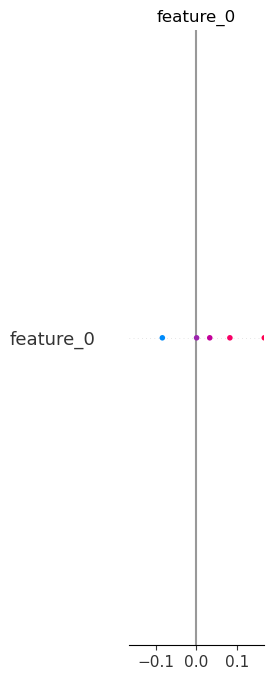

In [19]:
# 6. Visualizar
shap.summary_plot(shap_values, X_explain.numpy(), 
                  feature_names=[f'feature_{i}' for i in range(10)])

In [22]:
import torch
import shap
import numpy as np

In [23]:
# Tu modelo (probablemente con dimensiones incorrectas)
class TuModelo(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 20)  # Entrada: 10, Salida: 20
        self.fc2 = nn.Linear(20, 1)   # Entrada: 20, Salida: 1
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [24]:
model = TuModelo().eval()

# Verificar dimensiones de los datos
print(f"Dimensiones del modelo:")
print(f"  fc1 espera: {model.fc1.in_features} features")
print(f"  fc1 produce: {model.fc1.out_features} features")
print(f"  fc2 espera: {model.fc2.in_features} features")

# Verificar datos de entrada
X = torch.randn(100, 10)  # 100 muestras, 10 características
print(f"\nDimensiones de X: {X.shape}")  # Debería ser [100, 10]

background = X[:50]
print(f"Background shape: {background.shape}")  # [50, 10]

Dimensiones del modelo:
  fc1 espera: 10 features
  fc1 produce: 20 features
  fc2 espera: 20 features

Dimensiones de X: torch.Size([100, 10])
Background shape: torch.Size([50, 10])


In [25]:
class ModeloCorregido(nn.Module):
    def __init__(self, input_dim=10):
        super().__init__()
        # Asegurar que todas las dimensiones sean consistentes
        self.fc1 = nn.Linear(input_dim, 20)
        self.fc2 = nn.Linear(20, 15)  # Dimensión intermedia
        self.fc3 = nn.Linear(15, 1)   # Salida final
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

model = ModeloCorregido(input_dim=10).eval()
print(f"Modelo corregido:")
print(f"  Entrada esperada: {model.fc1.in_features}")
print(f"  Salida final: {model.fc3.out_features}")

Modelo corregido:
  Entrada esperada: 10
  Salida final: 1
